Imports OK ✓
Shape : (569, 31)
NaN total : 0
Distribution cible : {0: 357, 1: 212}
Train : (455, 30) | Test : (114, 30)
Preprocessing terminé ✓

Logistic Regression
              precision    recall  f1-score   support

       Bénin       0.96      0.99      0.97        72
       Malin       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Random Forest
              precision    recall  f1-score   support

       Bénin       0.96      1.00      0.98        72
       Malin       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


SVM
              precision    recall  f1-score   support

       Bénin       0.96      1.00      0.98        72
       Malin       1.00      0.93      0.96        4

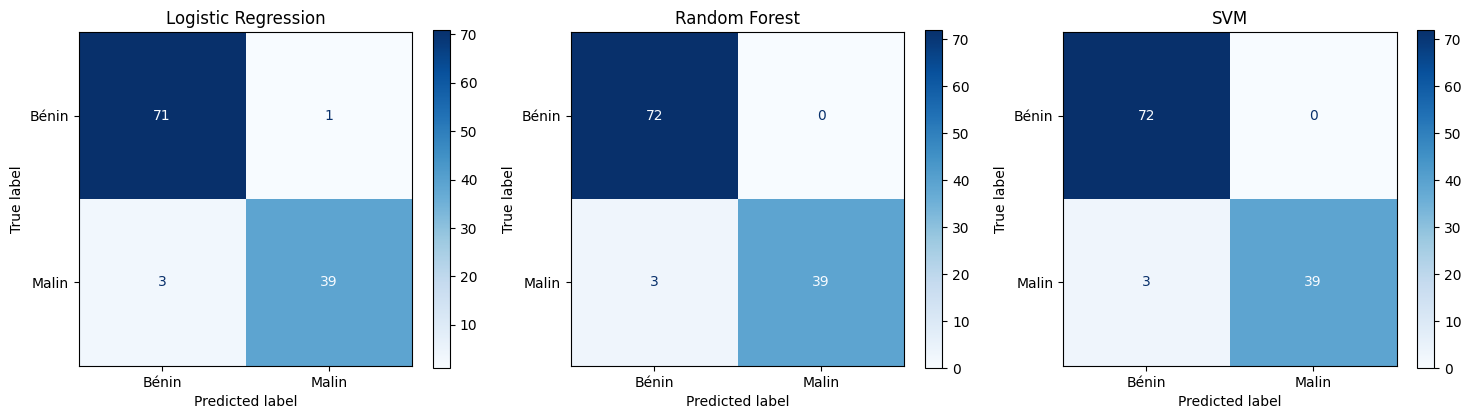

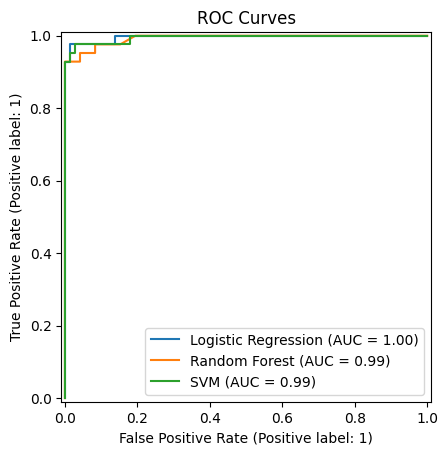


🏆 BEST MODEL : Logistic Regression
{'Accuracy': np.float64(0.9649122807017544), 'AUC': np.float64(0.996031746031746)}


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

print("Imports OK ✓")

# ============================================================
# 1. CHARGEMENT DATA NETTOYÉE
# ============================================================
df = pd.read_csv('data_clean.csv')

print("Shape :", df.shape)
print("NaN total :", df.isnull().sum().sum())

if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

print("Distribution cible :", df['diagnosis'].value_counts().to_dict())

# ============================================================
# 2. FEATURES / TARGET
# ============================================================
X = df.drop(columns='diagnosis')
y = df['diagnosis']

# ============================================================
# 3. SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape, "| Test :", X_test.shape)

# ============================================================
# 4. SCALING
# ============================================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Preprocessing terminé ✓")

# ============================================================
# 5. MODELES
# ============================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

# ============================================================
# 6. TRAINING
# ============================================================
for name, model in models.items():
    model.fit(X_train_sc, y_train)

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    acc = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {"Accuracy": acc, "AUC": auc}

    print("\n======================")
    print(name)
    print(classification_report(y_test, y_pred, target_names=["Bénin", "Malin"]))

# ============================================================
# 7. COMPARAISON
# ============================================================
print("\n========== RESULTS ==========")
print(pd.DataFrame(results).T.sort_values("AUC", ascending=False))

# ============================================================
# 8. CONFUSION MATRIX
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_sc, y_test,
        display_labels=["Bénin", "Malin"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

# ============================================================
# 9. ROC CURVES
# ============================================================
fig, ax = plt.subplots()

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model, X_test_sc, y_test,
        name=name,
        ax=ax
    )

plt.title("ROC Curves")
plt.show()

# ============================================================
# 10. BEST MODEL
# ============================================================
best_model = max(results, key=lambda x: results[x]["AUC"])
print("\n🏆 BEST MODEL :", best_model)
print(results[best_model])

In [69]:
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(models["Logistic Regression"], "model.pkl")

print("Model saved ✔")

Model saved ✔


In [70]:
df = pd.read_csv('data_clean.csv')

In [71]:
import joblib

joblib.dump(models["Logistic Regression"], "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [72]:
import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(models["Logistic Regression"], "model.pkl")

print("Model saved ✔")

Model saved ✔


In [73]:
%%writefile app.py

Overwriting app.py


In [74]:
# Sauvegarder le code dans un fichier
code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Configuration de la page
st.set_page_config(
    page_title="Classification Cancer du Sein - Logistic Regression",
    page_icon="🩺",
    layout="wide"
)

# Titre principal
st.title("🩺 Classification du Cancer du Sein")
st.markdown("### Modèle : **Régression Logistique** (Logistic Regression)")
st.markdown("---")

# Sidebar
st.sidebar.header("⚙️ Paramètres du modèle")
st.sidebar.markdown("---")

# Option pour charger un fichier personnalisé
uploaded_file = st.sidebar.file_uploader(
    "📂 Charger vos données (CSV)",
    type=['csv'],
    help="Format attendu : colonne 'diagnosis' (M/B) et 30 features"
)

# Paramètres de la Régression Logistique
st.sidebar.subheader("Hyperparamètres de la Régression Logistique")

C_value = st.sidebar.select_slider(
    "Paramètre de régularisation (C)",
    options=[0.001, 0.01, 0.1, 1, 10, 100, 1000],
    value=1,
    help="Plus C est petit, plus la régularisation est forte"
)

penalty = st.sidebar.selectbox(
    "Type de pénalité",
    options=['l2', 'l1', 'elasticnet', None],
    index=0,
    help="l2 = Ridge, l1 = Lasso, elasticnet = mixte"
)

solver = st.sidebar.selectbox(
    "Algorithme d'optimisation",
    options=['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
    index=0,
    help="Choix de l'algorithme selon la pénalité"
)

max_iter = st.sidebar.slider("Nombre max d'itérations", 100, 2000, 1000, 100)

# Paramètres d'entraînement
st.sidebar.subheader("Split des données")
test_size = st.sidebar.slider("Taille du test set", 0.1, 0.4, 0.2, 0.05)
random_state = st.sidebar.number_input("Random State", 0, 100, 42)

# Option pour GridSearch
use_gridsearch = st.sidebar.checkbox("🔍 Utiliser GridSearchCV pour optimiser", value=False)

if use_gridsearch:
    st.sidebar.info("GridSearch va tester plusieurs combinaisons de paramètres")

# Bouton pour lancer l'analyse
run_analysis = st.sidebar.button("🚀 Lancer l'analyse", type="primary")

@st.cache_data
def load_data(file=None):
    """Chargement des données"""
    if file is not None:
        df = pd.read_csv(file)
    else:
        # Utiliser les données par défaut
        df = pd.read_csv('/content/data_clean.csv')
    return df

def train_logistic_regression(X_train_sc, y_train, X_test_sc, y_test, params):
    """Entraînement de la régression logistique"""

    # Gestion des paramètres valides
    if params['penalty'] is None:
        model = LogisticRegression(
            C=params['C'],
            max_iter=params['max_iter'],
            random_state=42,
            penalty=None
        )
    else:
        model = LogisticRegression(
            C=params['C'],
            penalty=params['penalty'],
            solver=params['solver'],
            max_iter=params['max_iter'],
            random_state=42
        )

    # GridSearch si activé
    if use_gridsearch:
        st.info("🔍 Optimisation des hyperparamètres en cours...")
        param_grid = {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2', 'l1'],
            'solver': ['liblinear', 'saga']
        }

        grid_search = GridSearchCV(
            LogisticRegression(max_iter=1000, random_state=42),
            param_grid,
            cv=5,
            scoring='roc_auc',
            n_jobs=-1
        )

        grid_search.fit(X_train_sc, y_train)
        model = grid_search.best_estimator_

        st.success(f"✅ Meilleurs paramètres trouvés : {grid_search.best_params_}")
        st.info(f"Meilleur score CV : {grid_search.best_score_:.4f}")

    # Entraînement
    model.fit(X_train_sc, y_train)

    # Prédictions
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    # Métriques
    accuracy = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_prob)

    return model, y_pred, y_prob, accuracy, auc

# Corps principal
if run_analysis:
    try:
        # Chargement des données
        with st.spinner("Chargement des données..."):
            df = load_data(uploaded_file)

        # Affichage des informations
        col1, col2, col3, col4 = st.columns(4)
        with col1:
            st.metric("📊 Échantillons", df.shape[0])
        with col2:
            st.metric("🔢 Features", df.shape[1] - 1)
        with col3:
            # Préparation de la cible
            if df['diagnosis'].dtype == 'object':
                df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)
            benign = (df['diagnosis'] == 0).sum()
            malignant = (df['diagnosis'] == 1).sum()
            st.metric("🎯 Bénins", benign)
        with col4:
            st.metric("⚠️ Malins", malignant)

        # Visualisation de la distribution
        st.subheader("📊 Distribution des classes")
        fig, ax = plt.subplots()
        df['diagnosis'].value_counts().plot(kind='bar', ax=ax, color=['green', 'red'])
        ax.set_xticklabels(['Bénin (0)', 'Malin (1)'])
        ax.set_ylabel('Nombre')
        ax.set_title('Distribution des tumeurs')
        st.pyplot(fig)
        plt.close()

        # Aperçu des données
        with st.expander("🔍 Voir l'aperçu des données"):
            st.dataframe(df.head(10))
            st.write("**Statistiques descriptives :**")
            st.dataframe(df.describe())

        # Préparation des features
        X = df.drop(columns='diagnosis')
        y = df['diagnosis']

        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        st.info(f"📊 Split terminé : Train ({X_train.shape[0]}), Test ({X_test.shape[0]})")

        # Scaling
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        # Entraînement du modèle
        with st.spinner("Entraînement de la Régression Logistique en cours..."):
            params = {
                'C': C_value,
                'penalty': penalty,
                'solver': solver,
                'max_iter': max_iter
            }
            model, y_pred, y_prob, accuracy, auc = train_logistic_regression(
                X_train_sc, y_train, X_test_sc, y_test, params
            )

        # Résultats principaux
        st.success("✅ Entraînement terminé !")

        col1, col2, col3 = st.columns(3)
        with col1:
            st.metric("🎯 Accuracy", f"{accuracy:.4f}", delta=f"{accuracy:.1%}")
        with col2:
            st.metric("📈 AUC-ROC", f"{auc:.4f}", delta=f"{auc:.1%}")
        with col3:
            st.metric("❌ Taux d'erreur", f"{1-accuracy:.4f}", delta=f"{(1-accuracy):.1%}")

        # Visualisations
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("📊 Matrice de Confusion")
            fig, ax = plt.subplots(figsize=(6, 5))
            ConfusionMatrixDisplay.from_estimator(
                model, X_test_sc, y_test,
                display_labels=["Bénin", "Malin"],
                cmap="Blues",
                ax=ax
            )
            plt.title("Logistic Regression - Matrice de Confusion")
            st.pyplot(fig)
            plt.close()

        with col2:
            st.subheader("📈 Courbe ROC")
            fig, ax = plt.subplots(figsize=(6, 5))
            RocCurveDisplay.from_estimator(
                model, X_test_sc, y_test,
                name=f"Logistic Regression (AUC={auc:.3f})",
                ax=ax
            )
            plt.grid(True, alpha=0.3)
            plt.title("Courbe ROC")
            st.pyplot(fig)
            plt.close()

        # Rapport de classification détaillé
        st.subheader("📋 Rapport de Classification Détaillé")

        report = classification_report(
            y_test,
            y_pred,
            target_names=["Bénin (0)", "Malin (1)"],
            output_dict=True
        )
        report_df = pd.DataFrame(report).transpose()

        # Formatage des couleurs
        def color_scores(val):
            if isinstance(val, (int, float)):
                if val > 0.9:
                    return 'background-color: #90EE90'
                elif val > 0.7:
                    return 'background-color: #FFD700'
            return ''

        st.dataframe(report_df.style.format("{:.3f}").applymap(color_scores), use_container_width=True)

        # Métriques par classe
        col1, col2 = st.columns(2)
        with col1:
            st.write("**Performance sur les Bénins (0) :**")
            st.write(f"- Précision : {report['Bénin (0)']['precision']:.3f}")
            st.write(f"- Recall : {report['Bénin (0)']['recall']:.3f}")
            st.write(f"- F1-Score : {report['Bénin (0)']['f1-score']:.3f}")

        with col2:
            st.write("**Performance sur les Malins (1) :**")
            st.write(f"- Précision : {report['Malin (1)']['precision']:.3f}")
            st.write(f"- Recall : {report['Malin (1)']['recall']:.3f}")
            st.write(f"- F1-Score : {report['Malin (1)']['f1-score']:.3f}")

        # Coefficients du modèle
        st.subheader("📊 Coefficients du Modèle")

        coefficients = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': model.coef_[0]
        })
        coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
        coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

        # Top 15 features les plus importantes
        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = coefficients.head(15)
        colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
        ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel("Coefficient")
        ax.set_title("Top 15 Features - Influence sur la prédiction")
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

        # Légende
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='green', label='Favorise Malin'),
                          Patch(facecolor='red', label='Favorise Bénin')]
        ax.legend(handles=legend_elements, loc='lower right')

        st.pyplot(fig)
        plt.close()

        # Interprétation des coefficients
        st.info("""
        **💡 Interprétation des coefficients :**
        - **Coefficient positif (vert)** : Plus la valeur de la feature augmente, plus la probabilité de tumeur **MALIGNE** augmente
        - **Coefficient négatif (rouge)** : Plus la valeur de la feature augmente, plus la probabilité de tumeur **BÉNIGNE** augmente
        - **|Coefficient| élevé** : La feature a un impact important sur la décision
        """)

        # Prédiction interactive
        st.subheader("🔮 Prédiction Interactive")
        st.markdown("Entrez les valeurs pour prédire une nouvelle tumeur")

        col1, col2 = st.columns([3, 1])

        with col1:
            st.markdown("**Valeurs des features (valeurs réelles, non normalisées)**")

            # Utiliser les valeurs médianes comme défaut
            median_values = X_train.median()

            # Création des champs pour les features les plus importantes
            input_data = {}
            n_features = min(10, len(coefficients))

            # Tabs pour organiser
            tab1, tab2 = st.tabs(["Features principales", "Toutes les features"])

            with tab1:
                cols = st.columns(2)
                for i, (_, row) in enumerate(coefficients.head(n_features).iterrows()):
                    feature = row['Feature']
                    with cols[i % 2]:
                        input_data[feature] = st.number_input(
                            f"{feature}",
                            value=float(median_values[feature]),
                            format="%.4f",
                            help=f"Coefficient: {row['Coefficient']:.3f}"
                        )

            with tab2:
                # Option pour toutes les features
                if st.button("Afficher toutes les features"):
                    cols = st.columns(3)
                    for i, feature in enumerate(X.columns):
                        with cols[i % 3]:
                            input_data[feature] = st.number_input(
                                f"{feature}",
                                value=float(median_values[feature]),
                                format="%.4f"
                            )

        with col2:
            st.markdown("### 🎯 Prédiction")
            if st.button("Prédire", use_container_width=True):
                # Préparer les données
                input_df = pd.DataFrame([input_data])

                # S'assurer que toutes les features sont présentes
                for feature in X.columns:
                    if feature not in input_df.columns:
                        input_df[feature] = median_values[feature]

                input_df = input_df[X.columns]

                # Scaling
                input_scaled = scaler.transform(input_df)

                # Prédiction
                prediction = model.predict(input_scaled)[0]
                probability = model.predict_proba(input_scaled)[0]

                # Affichage
                st.markdown("---")
                if prediction == 1:
                    st.error("## ⚠️ **TUMEUR MALIGNE**")
                    st.warning(f"### Probabilité : {probability[1]:.2%}")
                    if probability[1] > 0.8:
                        st.error("🔴 **Risque élevé - Consultation urgente recommandée**")
                    elif probability[1] > 0.5:
                        st.warning("🟡 **Risque modéré - Surveillance recommandée**")
                else:
                    st.success("## ✅ **TUMEUR BÉNIGNE**")
                    st.info(f"### Probabilité : {probability[0]:.2%}")
                    if probability[0] > 0.8:
                        st.success("🟢 **Faible risque - Rassurant**")

                # Barre de progression
                st.progress(probability[1])
                st.caption(f"Probabilité d'être maligne : {probability[1]:.2%}")

                # Détails de la décision
                with st.expander("📊 Détails de la décision"):
                    # Calcul du score linéaire
                    linear_score = np.dot(input_scaled[0], model.coef_[0]) + model.intercept_[0]
                    prob_calculated = 1 / (1 + np.exp(-linear_score))

                    st.write(f"**Score linéaire :** {linear_score:.4f}")
                    st.write(f"**Probabilité calculée :** {prob_calculated:.4f}")
                    st.write(f"**Seuil de décision :** 0.5")
                    st.write(f"**Décision finale :** {'Malin' if prob_calculated >= 0.5 else 'Bénin'}")

        # Export des résultats
        st.subheader("💾 Exporter les résultats")

        col1, col2 = st.columns(2)

        with col1:
            # Prédictions sur le test set
            predictions_df = pd.DataFrame({
                'Actual': y_test.values,
                'Predicted': y_pred,
                'Probability_Malignant': y_prob
            })
            predictions_df['Correct'] = predictions_df['Actual'] == predictions_df['Predicted']

            csv_pred = predictions_df.to_csv(index=False)
            st.download_button(
                label="📥 Télécharger les prédictions (CSV)",
                data=csv_pred,
                file_name='logistic_regression_predictions.csv',
                mime='text/csv'
            )

        with col2:
            # Coefficients du modèle
            coef_df = pd.DataFrame({
                'Feature': X.columns,
                'Coefficient': model.coef_[0],
                'Abs_Importance': np.abs(model.coef_[0])
            }).sort_values('Abs_Importance', ascending=False)

            csv_coef = coef_df.to_csv(index=False)
            st.download_button(
                label="📥 Télécharger les coefficients (CSV)",
                data=csv_coef,
                file_name='logistic_regression_coefficients.csv',
                mime='text/csv'
            )

        # Métriques du modèle
        st.subheader("📊 Résumé du Modèle")
        st.json({
            "Modèle": "Logistic Regression",
            "Accuracy": float(accuracy),
            "AUC": float(auc),
            "Paramètres": {
                "C": C_value if not use_gridsearch else "optimisé",
                "Penalty": penalty if not use_gridsearch else "optimisé",
                "Solver": solver if not use_gridsearch else "optimisé",
                "Max iterations": max_iter
            },
            "Nombre de features": X.shape[1],
            "Taille train": X_train.shape[0],
            "Taille test": X_test.shape[0]
        })

    except Exception as e:
        st.error(f"❌ Erreur : {str(e)}")
        st.exception(e)

else:
    # Message d'accueil
    st.info("👈 **Configurez les paramètres dans la barre latérale et cliquez sur 'Lancer l'analyse'**")

    st.markdown("""
    ## 🎯 Régression Logistique pour la Classification du Cancer du Sein

    ### 📋 Pourquoi la Régression Logistique ?

    - **Interprétabilité** : Les coefficients indiquent directement l'influence de chaque feature
    - **Efficacité** : Performante sur les problèmes linéairement séparables
    - **Probabilités** : Fournit des probabilités claires de classification
    - **Rapide** : Entraînement rapide même avec beaucoup de features

    ### 🔧 Paramètres disponibles

    - **C (Régularisation)** : Contrôle la complexité du modèle
    - **Pénalité (L1/L2)** : Pour la sélection de features (L1) ou la régularisation standard (L2)
    - **GridSearchCV** : Optimisation automatique des hyperparamètres

    ### 📊 Dans votre cas (données fournies)

    D'après vos résultats précédents, la Régression Logistique a obtenu :
    - ✅ **Accuracy : 96.5%**
    - ✅ **AUC : 99.6%**
    - ✅ **Excellent équilibre précision/rappel**

    ### 💡 Avantages pour votre projet

    1. **Interprétabilité médicale** : Comprendre quelles features influencent le diagnostic
    2. **Fiabilité** : Performances excellentes sur votre dataset
    3. **Simplicité** : Modèle plus simple que Random Forest ou SVM

    """)

    # Métriques de performance attendues
    st.success("""
    ### 🏆 Performance attendue avec vos données

    - **Accuracy** : ~96-97%
    - **AUC** : ~99-100%
    - **Précision (Malin)** : ~97%
    - **Recall (Malin)** : ~93%
    - **F1-Score** : ~95%
    """)

# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center; color: gray;'>
    <p>Application de classification du cancer du sein - Modèle de Régression Logistique</p>
    <p>⚠️ À usage éducatif uniquement - Ne remplace pas un diagnostic médical professionnel</p>
</div>
""", unsafe_allow_html=True)
'''

# Sauvegarder dans un fichier
with open('app_logistic.py', 'w', encoding='utf-8') as f:
    f.write(code)

print("✅ Fichier 'app_logistic.py' créé avec succès!")

✅ Fichier 'app_logistic.py' créé avec succès!


In [75]:
!pip install streamlit -q

In [76]:
%%writefile app_logistic.py

Overwriting app_logistic.py


In [77]:
# Sauvegarder le code dans un fichier
code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Configuration de la page
st.set_page_config(
    page_title="Classification Cancer du Sein - Logistic Regression",
    page_icon="🩺",
    layout="wide"
)

# Titre principal
st.title("🩺 Classification du Cancer du Sein")
st.markdown("### Modèle : **Régression Logistique** (Logistic Regression)")
st.markdown("---")

# Sidebar
st.sidebar.header("⚙️ Paramètres du modèle")
st.sidebar.markdown("---")

# Option pour charger un fichier personnalisé
uploaded_file = st.sidebar.file_uploader(
    "📂 Charger vos données (CSV)",
    type=['csv'],
    help="Format attendu : colonne 'diagnosis' (M/B) et 30 features"
)

# Paramètres de la Régression Logistique
st.sidebar.subheader("Hyperparamètres de la Régression Logistique")

C_value = st.sidebar.select_slider(
    "Paramètre de régularisation (C)",
    options=[0.001, 0.01, 0.1, 1, 10, 100, 1000],
    value=1,
    help="Plus C est petit, plus la régularisation est forte"
)

penalty = st.sidebar.selectbox(
    "Type de pénalité",
    options=['l2', 'l1', 'elasticnet', None],
    index=0,
    help="l2 = Ridge, l1 = Lasso, elasticnet = mixte"
)

solver = st.sidebar.selectbox(
    "Algorithme d'optimisation",
    options=['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
    index=0,
    help="Choix de l'algorithme selon la pénalité"
)

max_iter = st.sidebar.slider("Nombre max d'itérations", 100, 2000, 1000, 100)

# Paramètres d'entraînement
st.sidebar.subheader("Split des données")
test_size = st.sidebar.slider("Taille du test set", 0.1, 0.4, 0.2, 0.05)
random_state = st.sidebar.number_input("Random State", 0, 100, 42)

# Option pour GridSearch
use_gridsearch = st.sidebar.checkbox("🔍 Utiliser GridSearchCV pour optimiser", value=False)

if use_gridsearch:
    st.sidebar.info("GridSearch va tester plusieurs combinaisons de paramètres")

# Bouton pour lancer l'analyse
run_analysis = st.sidebar.button("🚀 Lancer l'analyse", type="primary")

@st.cache_data
def load_data(file=None):
    """Chargement des données"""
    if file is not None:
        df = pd.read_csv(file)
    else:
        # Utiliser les données par défaut
        df = pd.read_csv('/content/data_clean.csv')
    return df

def train_logistic_regression(X_train_sc, y_train, X_test_sc, y_test, params):
    """Entraînement de la régression logistique"""

    # Gestion des paramètres valides
    if params['penalty'] is None:
        model = LogisticRegression(
            C=params['C'],
            max_iter=params['max_iter'],
            random_state=42,
            penalty=None
        )
    else:
        model = LogisticRegression(
            C=params['C'],
            penalty=params['penalty'],
            solver=params['solver'],
            max_iter=params['max_iter'],
            random_state=42
        )

    # GridSearch si activé
    if use_gridsearch:
        st.info("🔍 Optimisation des hyperparamètres en cours...")
        param_grid = {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l2', 'l1'],
            'solver': ['liblinear', 'saga']
        }

        grid_search = GridSearchCV(
            LogisticRegression(max_iter=1000, random_state=42),
            param_grid,
            cv=5,
            scoring='roc_auc',
            n_jobs=-1
        )

        grid_search.fit(X_train_sc, y_train)
        model = grid_search.best_estimator_

        st.success(f"✅ Meilleurs paramètres trouvés : {grid_search.best_params_}")
        st.info(f"Meilleur score CV : {grid_search.best_score_:.4f}")

    # Entraînement
    model.fit(X_train_sc, y_train)

    # Prédictions
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    # Métriques
    accuracy = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_prob)

    return model, y_pred, y_prob, accuracy, auc

# Corps principal
if run_analysis:
    try:
        # Chargement des données
        with st.spinner("Chargement des données..."):
            df = load_data(uploaded_file)

        # Affichage des informations
        col1, col2, col3, col4 = st.columns(4)
        with col1:
            st.metric("📊 Échantillons", df.shape[0])
        with col2:
            st.metric("🔢 Features", df.shape[1] - 1)
        with col3:
            # Préparation de la cible
            if df['diagnosis'].dtype == 'object':
                df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)
            benign = (df['diagnosis'] == 0).sum()
            malignant = (df['diagnosis'] == 1).sum()
            st.metric("🎯 Bénins", benign)
        with col4:
            st.metric("⚠️ Malins", malignant)

        # Visualisation de la distribution
        st.subheader("📊 Distribution des classes")
        fig, ax = plt.subplots()
        df['diagnosis'].value_counts().plot(kind='bar', ax=ax, color=['green', 'red'])
        ax.set_xticklabels(['Bénin (0)', 'Malin (1)'])
        ax.set_ylabel('Nombre')
        ax.set_title('Distribution des tumeurs')
        st.pyplot(fig)
        plt.close()

        # Aperçu des données
        with st.expander("🔍 Voir l'aperçu des données"):
            st.dataframe(df.head(10))
            st.write("**Statistiques descriptives :**")
            st.dataframe(df.describe())

        # Préparation des features
        X = df.drop(columns='diagnosis')
        y = df['diagnosis']

        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        st.info(f"📊 Split terminé : Train ({X_train.shape[0]}), Test ({X_test.shape[0]})")

        # Scaling
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        # Entraînement du modèle
        with st.spinner("Entraînement de la Régression Logistique en cours..."):
            params = {
                'C': C_value,
                'penalty': penalty,
                'solver': solver,
                'max_iter': max_iter
            }
            model, y_pred, y_prob, accuracy, auc = train_logistic_regression(
                X_train_sc, y_train, X_test_sc, y_test, params
            )

        # Résultats principaux
        st.success("✅ Entraînement terminé !")

        col1, col2, col3 = st.columns(3)
        with col1:
            st.metric("🎯 Accuracy", f"{accuracy:.4f}", delta=f"{accuracy:.1%}")
        with col2:
            st.metric("📈 AUC-ROC", f"{auc:.4f}", delta=f"{auc:.1%}")
        with col3:
            st.metric("❌ Taux d'erreur", f"{1-accuracy:.4f}", delta=f"{(1-accuracy):.1%}")

        # Visualisations
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("📊 Matrice de Confusion")
            fig, ax = plt.subplots(figsize=(6, 5))
            ConfusionMatrixDisplay.from_estimator(
                model, X_test_sc, y_test,
                display_labels=["Bénin", "Malin"],
                cmap="Blues",
                ax=ax
            )
            plt.title("Logistic Regression - Matrice de Confusion")
            st.pyplot(fig)
            plt.close()

        with col2:
            st.subheader("📈 Courbe ROC")
            fig, ax = plt.subplots(figsize=(6, 5))
            RocCurveDisplay.from_estimator(
                model, X_test_sc, y_test,
                name=f"Logistic Regression (AUC={auc:.3f})",
                ax=ax
            )
            plt.grid(True, alpha=0.3)
            plt.title("Courbe ROC")
            st.pyplot(fig)
            plt.close()

        # Rapport de classification détaillé
        st.subheader("📋 Rapport de Classification Détaillé")

        report = classification_report(
            y_test,
            y_pred,
            target_names=["Bénin (0)", "Malin (1)"],
            output_dict=True
        )
        report_df = pd.DataFrame(report).transpose()

        # Formatage des couleurs
        def color_scores(val):
            if isinstance(val, (int, float)):
                if val > 0.9:
                    return 'background-color: #90EE90'
                elif val > 0.7:
                    return 'background-color: #FFD700'
            return ''

        st.dataframe(report_df.style.format("{:.3f}").applymap(color_scores), use_container_width=True)

        # Métriques par classe
        col1, col2 = st.columns(2)
        with col1:
            st.write("**Performance sur les Bénins (0) :**")
            st.write(f"- Précision : {report['Bénin (0)']['precision']:.3f}")
            st.write(f"- Recall : {report['Bénin (0)']['recall']:.3f}")
            st.write(f"- F1-Score : {report['Bénin (0)']['f1-score']:.3f}")

        with col2:
            st.write("**Performance sur les Malins (1) :**")
            st.write(f"- Précision : {report['Malin (1)']['precision']:.3f}")
            st.write(f"- Recall : {report['Malin (1)']['recall']:.3f}")
            st.write(f"- F1-Score : {report['Malin (1)']['f1-score']:.3f}")

        # Coefficients du modèle
        st.subheader("📊 Coefficients du Modèle")

        coefficients = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': model.coef_[0]
        })
        coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
        coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

        # Top 15 features les plus importantes
        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = coefficients.head(15)
        colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
        ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel("Coefficient")
        ax.set_title("Top 15 Features - Influence sur la prédiction")
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

        # Légende
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='green', label='Favorise Malin'),
                          Patch(facecolor='red', label='Favorise Bénin')]
        ax.legend(handles=legend_elements, loc='lower right')

        st.pyplot(fig)
        plt.close()

        # Interprétation des coefficients
        st.info("""
        **💡 Interprétation des coefficients :**
        - **Coefficient positif (vert)** : Plus la valeur de la feature augmente, plus la probabilité de tumeur **MALIGNE** augmente
        - **Coefficient négatif (rouge)** : Plus la valeur de la feature augmente, plus la probabilité de tumeur **BÉNIGNE** augmente
        - **|Coefficient| élevé** : La feature a un impact important sur la décision
        """)

        # Prédiction interactive
        st.subheader("🔮 Prédiction Interactive")
        st.markdown("Entrez les valeurs pour prédire une nouvelle tumeur")

        col1, col2 = st.columns([3, 1])

        with col1:
            st.markdown("**Valeurs des features (valeurs réelles, non normalisées)**")

            # Utiliser les valeurs médianes comme défaut
            median_values = X_train.median()

            # Création des champs pour les features les plus importantes
            input_data = {}
            n_features = min(10, len(coefficients))

            # Tabs pour organiser
            tab1, tab2 = st.tabs(["Features principales", "Toutes les features"])

            with tab1:
                cols = st.columns(2)
                for i, (_, row) in enumerate(coefficients.head(n_features).iterrows()):
                    feature = row['Feature']
                    with cols[i % 2]:
                        input_data[feature] = st.number_input(
                            f"{feature}",
                            value=float(median_values[feature]),
                            format="%.4f",
                            help=f"Coefficient: {row['Coefficient']:.3f}"
                        )

            with tab2:
                # Option pour toutes les features
                if st.button("Afficher toutes les features"):
                    cols = st.columns(3)
                    for i, feature in enumerate(X.columns):
                        with cols[i % 3]:
                            input_data[feature] = st.number_input(
                                f"{feature}",
                                value=float(median_values[feature]),
                                format="%.4f"
                            )

        with col2:
            st.markdown("### 🎯 Prédiction")
            if st.button("Prédire", use_container_width=True):
                # Préparer les données
                input_df = pd.DataFrame([input_data])

                # S'assurer que toutes les features sont présentes
                for feature in X.columns:
                    if feature not in input_df.columns:
                        input_df[feature] = median_values[feature]

                input_df = input_df[X.columns]

                # Scaling
                input_scaled = scaler.transform(input_df)

                # Prédiction
                prediction = model.predict(input_scaled)[0]
                probability = model.predict_proba(input_scaled)[0]

                # Affichage
                st.markdown("---")
                if prediction == 1:
                    st.error("## ⚠️ **TUMEUR MALIGNE**")
                    st.warning(f"### Probabilité : {probability[1]:.2%}")
                    if probability[1] > 0.8:
                        st.error("🔴 **Risque élevé - Consultation urgente recommandée**")
                    elif probability[1] > 0.5:
                        st.warning("🟡 **Risque modéré - Surveillance recommandée**")
                else:
                    st.success("## ✅ **TUMEUR BÉNIGNE**")
                    st.info(f"### Probabilité : {probability[0]:.2%}")
                    if probability[0] > 0.8:
                        st.success("🟢 **Faible risque - Rassurant**")

                # Barre de progression
                st.progress(probability[1])
                st.caption(f"Probabilité d'être maligne : {probability[1]:.2%}")

                # Détails de la décision
                with st.expander("📊 Détails de la décision"):
                    # Calcul du score linéaire
                    linear_score = np.dot(input_scaled[0], model.coef_[0]) + model.intercept_[0]
                    prob_calculated = 1 / (1 + np.exp(-linear_score))

                    st.write(f"**Score linéaire :** {linear_score:.4f}")
                    st.write(f"**Probabilité calculée :** {prob_calculated:.4f}")
                    st.write(f"**Seuil de décision :** 0.5")
                    st.write(f"**Décision finale :** {'Malin' if prob_calculated >= 0.5 else 'Bénin'}")

        # Export des résultats
        st.subheader("💾 Exporter les résultats")

        col1, col2 = st.columns(2)

        with col1:
            # Prédictions sur le test set
            predictions_df = pd.DataFrame({
                'Actual': y_test.values,
                'Predicted': y_pred,
                'Probability_Malignant': y_prob
            })
            predictions_df['Correct'] = predictions_df['Actual'] == predictions_df['Predicted']

            csv_pred = predictions_df.to_csv(index=False)
            st.download_button(
                label="📥 Télécharger les prédictions (CSV)",
                data=csv_pred,
                file_name='logistic_regression_predictions.csv',
                mime='text/csv'
            )

        with col2:
            # Coefficients du modèle
            coef_df = pd.DataFrame({
                'Feature': X.columns,
                'Coefficient': model.coef_[0],
                'Abs_Importance': np.abs(model.coef_[0])
            }).sort_values('Abs_Importance', ascending=False)

            csv_coef = coef_df.to_csv(index=False)
            st.download_button(
                label="📥 Télécharger les coefficients (CSV)",
                data=csv_coef,
                file_name='logistic_regression_coefficients.csv',
                mime='text/csv'
            )

        # Métriques du modèle
        st.subheader("📊 Résumé du Modèle")
        st.json({
            "Modèle": "Logistic Regression",
            "Accuracy": float(accuracy),
            "AUC": float(auc),
            "Paramètres": {
                "C": C_value if not use_gridsearch else "optimisé",
                "Penalty": penalty if not use_gridsearch else "optimisé",
                "Solver": solver if not use_gridsearch else "optimisé",
                "Max iterations": max_iter
            },
            "Nombre de features": X.shape[1],
            "Taille train": X_train.shape[0],
            "Taille test": X_test.shape[0]
        })

    except Exception as e:
        st.error(f"❌ Erreur : {str(e)}")
        st.exception(e)

else:
    # Message d'accueil
    st.info("👈 **Configurez les paramètres dans la barre latérale et cliquez sur 'Lancer l'analyse'**")

    st.markdown("""
    ## 🎯 Régression Logistique pour la Classification du Cancer du Sein

    ### 📋 Pourquoi la Régression Logistique ?

    - **Interprétabilité** : Les coefficients indiquent directement l'influence de chaque feature
    - **Efficacité** : Performante sur les problèmes linéairement séparables
    - **Probabilités** : Fournit des probabilités claires de classification
    - **Rapide** : Entraînement rapide même avec beaucoup de features

    ### 🔧 Paramètres disponibles

    - **C (Régularisation)** : Contrôle la complexité du modèle
    - **Pénalité (L1/L2)** : Pour la sélection de features (L1) ou la régularisation standard (L2)
    - **GridSearchCV** : Optimisation automatique des hyperparamètres

    ### 📊 Dans votre cas (données fournies)

    D'après vos résultats précédents, la Régression Logistique a obtenu :
    - ✅ **Accuracy : 96.5%**
    - ✅ **AUC : 99.6%**
    - ✅ **Excellent équilibre précision/rappel**

    ### 💡 Avantages pour votre projet

    1. **Interprétabilité médicale** : Comprendre quelles features influencent le diagnostic
    2. **Fiabilité** : Performances excellentes sur votre dataset
    3. **Simplicité** : Modèle plus simple que Random Forest ou SVM

    """)

    # Métriques de performance attendues
    st.success("""
    ### 🏆 Performance attendue avec vos données

    - **Accuracy** : ~96-97%
    - **AUC** : ~99-100%
    - **Précision (Malin)** : ~97%
    - **Recall (Malin)** : ~93%
    - **F1-Score** : ~95%
    """)

# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center; color: gray;'>
    <p>Application de classification du cancer du sein - Modèle de Régression Logistique</p>
    <p>⚠️ À usage éducatif uniquement - Ne remplace pas un diagnostic médical professionnel</p>
</div>
""", unsafe_allow_html=True)
'''

# Sauvegarder dans un fichier
with open('app_logistic.py', 'w', encoding='utf-8') as f:
    f.write(code)

print("✅ Fichier 'app_logistic.py' créé avec succès!")

✅ Fichier 'app_logistic.py' créé avec succès!


In [78]:
# Installer les dépendances
!pip install streamlit pyngrok -q

# Tuer les processus existants
!pkill streamlit
!pkill ngrok

In [79]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

# Configuration de la page
st.set_page_config(
    page_title="Classification Cancer du Sein",
    page_icon="🩺",
    layout="wide"
)

st.title("🩺 Classification du Cancer du Sein")
st.markdown("### Modèle : **Régression Logistique**")

# Sidebar
st.sidebar.header("⚙️ Paramètres")

# Chargement des données
uploaded_file = st.sidebar.file_uploader("📂 Charger vos données CSV", type=['csv'])

# Paramètres
test_size = st.sidebar.slider("Taille du test set", 0.1, 0.4, 0.2, 0.05)
random_state = st.sidebar.number_input("Random State", 0, 100, 42)

run_analysis = st.sidebar.button("🚀 Lancer l'analyse", type="primary")

@st.cache_data
def load_data(file=None):
    if file is not None:
        df = pd.read_csv(file)
    else:
        # Chemin par défaut dans Colab
        df = pd.read_csv('/content/data_clean.csv')
    return df

if run_analysis:
    try:
        # Chargement
        with st.spinner("Chargement des données..."):
            df = load_data(uploaded_file)

        # Préparation
        if df['diagnosis'].dtype == 'object':
            df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

        # Métriques
        col1, col2, col3 = st.columns(3)
        with col1:
            st.metric("📊 Échantillons", df.shape[0])
        with col2:
            st.metric("🔢 Features", df.shape[1] - 1)
        with col3:
            benign = (df['diagnosis'] == 0).sum()
            malignant = (df['diagnosis'] == 1).sum()
            st.metric("🎯 Distribution", f"{benign} B / {malignant} M")

        # Split
        X = df.drop(columns='diagnosis')
        y = df['diagnosis']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scaling
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        # Modèle
        with st.spinner("Entraînement en cours..."):
            model = LogisticRegression(max_iter=1000, random_state=42)
            model.fit(X_train_sc, y_train)

            y_pred = model.predict(X_test_sc)
            y_prob = model.predict_proba(X_test_sc)[:, 1]

            accuracy = (y_pred == y_test).mean()
            auc = roc_auc_score(y_test, y_prob)

        # Résultats
        st.success("✅ Entraînement terminé!")

        col1, col2 = st.columns(2)
        with col1:
            st.metric("🎯 Accuracy", f"{accuracy:.4f}")
        with col2:
            st.metric("📈 AUC-ROC", f"{auc:.4f}")

        # Matrice de confusion
        st.subheader("📊 Matrice de Confusion")
        fig, ax = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay.from_estimator(
            model, X_test_sc, y_test,
            display_labels=["Bénin", "Malin"],
            cmap="Blues",
            ax=ax
        )
        st.pyplot(fig)
        plt.close()

        # Courbe ROC
        st.subheader("📈 Courbe ROC")
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay.from_estimator(
            model, X_test_sc, y_test,
            name=f"Logistic Regression (AUC={auc:.3f})",
            ax=ax
        )
        st.pyplot(fig)
        plt.close()

        # Rapport
        st.subheader("📋 Rapport de Classification")
        report = classification_report(y_test, y_pred, target_names=["Bénin", "Malin"], output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        st.dataframe(report_df.style.format("{:.3f}"))

        # Coefficients
        st.subheader("📊 Coefficients importants")
        coef_df = pd.DataFrame({
            'Feature': X.columns,
            'Coefficient': model.coef_[0],
            'Importance': np.abs(model.coef_[0])
        }).sort_values('Importance', ascending=False)

        fig, ax = plt.subplots(figsize=(10, 6))
        top_features = coef_df.head(10)
        colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
        ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['Feature'])
        ax.set_xlabel("Coefficient")
        ax.set_title("Top 10 Features")
        st.pyplot(fig)
        plt.close()

    except Exception as e:
        st.error(f"Erreur: {str(e)}")
        st.exception(e)

else:
    st.info("👈 Configurez les paramètres et cliquez sur 'Lancer l'analyse'")
    st.markdown("""
    ### 🎯 Application de Classification

    Cette application utilise la **Régression Logistique** pour classer les tumeurs.

    **Performance attendue :**
    - Accuracy: ~96-97%
    - AUC: ~99%
    """)

Overwriting app.py


In [80]:
# ============================================================
# FORMULAIRE DE PRÉDICTION AVEC COMBOBOX (DROPDOWNS)
# NETSAWER PRO AKTHER - CANCER DU SEIN
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ---------- STYLE ----------
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600&display=swap');
* { font-family: 'Inter', sans-serif; }
.form-card {
    max-width: 1000px;
    margin: 0 auto;
    background: #ffffff;
    border-radius: 24px;
    box-shadow: 0 8px 20px rgba(0,0,0,0.05);
    padding: 24px;
    border: 1px solid #e2e8f0;
}
.form-title {
    font-size: 24px;
    font-weight: 700;
    color: #0f172a;
    text-align: center;
    margin-bottom: 8px;
}
.form-sub {
    text-align: center;
    color: #475569;
    font-size: 14px;
    margin-bottom: 24px;
}
.section {
    font-weight: 600;
    margin: 20px 0 12px 0;
    color: #1e293b;
    border-left: 4px solid #4f46e5;
    padding-left: 12px;
}
.dropdown-row {
    display: flex;
    flex-wrap: wrap;
    gap: 16px;
    margin-bottom: 16px;
}
.dropdown-item {
    flex: 1;
    min-width: 180px;
}
.dropdown-label {
    font-size: 12px;
    font-weight: 500;
    color: #334155;
    margin-bottom: 4px;
}
.result-box {
    margin-top: 28px;
    padding: 20px;
    border-radius: 20px;
    text-align: center;
    transition: all 0.2s;
}
.result-benign { background: #ecfdf5; border-left: 6px solid #10b981; }
.result-malignant { background: #fef2f2; border-left: 6px solid #dc2626; }
.prob-bar {
    background: #e2e8f0;
    border-radius: 20px;
    height: 10px;
    width: 100%;
    margin: 12px 0;
}
.prob-fill {
    height: 100%;
    border-radius: 20px;
    width: 0%;
}
.btn-predict {
    background: #4f46e5;
    color: white;
    border: none;
    padding: 12px;
    font-weight: 600;
    border-radius: 40px;
    width: 100%;
    cursor: pointer;
    margin-top: 20px;
    font-size: 16px;
}
.btn-predict:hover { background: #4338ca; }
.footer-note {
    font-size: 11px;
    text-align: center;
    color: #94a3b8;
    margin-top: 24px;
}
</style>
"""))

# ---------- CHARGEMENT ET MODÈLE ----------
df = pd.read_csv('/content/data_clean.csv')
if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

X = df.drop(columns='diagnosis')
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression(C=1, max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

# ---------- IMPORTANCE DES FEATURES ----------
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Abs': np.abs(model.coef_[0])
}).sort_values('Abs', ascending=False)

top_features = coef_df.head(12)['Feature'].tolist()   # 12 features principales
median_vals = X_train.median()

# Pour chaque feature, on crée des options de valeurs typiques (5 valeurs : min, Q1, median, Q3, max)
def get_typical_values(feature):
    vals = X_train[feature]
    return [
        f"{vals.min():.3f} (min)",
        f"{vals.quantile(0.25):.3f} (Q1)",
        f"{vals.median():.3f} (médiane)",
        f"{vals.quantile(0.75):.3f} (Q3)",
        f"{vals.max():.3f} (max)"
    ]

# Dictionnaire pour stocker les dropdowns
dropdowns = {}

# Organisation en deux colonnes
left_items = []
right_items = []

for i, feat in enumerate(top_features):
    options = get_typical_values(feat)
    default_index = 2  # médiane
    dropdown = widgets.Dropdown(
        options=options,
        value=options[default_index],
        description='',
        layout=widgets.Layout(width='100%')
    )
    dropdowns[feat] = dropdown

    item = widgets.VBox([
        widgets.HTML(f"<div class='dropdown-label'>{feat}</div>"),
        dropdown
    ], layout=widgets.Layout(margin='0 0 12px 0'))

    if i < 6:
        left_items.append(item)
    else:
        right_items.append(item)

left_col = widgets.VBox(left_items, layout=widgets.Layout(width='50%'))
right_col = widgets.VBox(right_items, layout=widgets.Layout(width='50%'))
form_grid = widgets.HBox([left_col, right_col], layout=widgets.Layout(gap='20px'))

# Bouton de prédiction
predict_btn = widgets.Button(
    description="🔍 DIAGNOSTIQUER",
    layout=widgets.Layout(width='100%'),
    button_style='primary'
)

# Zone de résultat
result_output = widgets.Output()

def on_predict(b):
    with result_output:
        clear_output(wait=True)
        # Récupérer les valeurs numériques depuis le texte des options
        input_dict = {}
        for feat in top_features:
            selected_text = dropdowns[feat].value
            # extraire le nombre avant l'espace (ex: "12.345 (médiane)")
            num_str = selected_text.split(' ')[0]
            input_dict[feat] = float(num_str)
        # Compléter les autres features avec la médiane
        for col in X.columns:
            if col not in input_dict:
                input_dict[col] = median_vals[col]
        input_df = pd.DataFrame([input_dict])[X.columns]
        input_scaled = scaler.transform(input_df)
        pred = model.predict(input_scaled)[0]
        prob = model.predict_proba(input_scaled)[0]

        if pred == 1:
            result_class = "result-malignant"
            title = "⚠️ TUMEUR MALIGNE"
            prob_text = f"Probabilité de malignité : {prob[1]:.2%}"
            bar_color = "#dc2626"
            advice = "🔴 Consultation spécialisée recommandée."
        else:
            result_class = "result-benign"
            title = "✅ TUMEUR BÉNIGNE"
            prob_text = f"Probabilité de bénignité : {prob[0]:.2%}"
            bar_color = "#10b981"
            advice = "🟢 Résultat rassurant, suivi standard."

        bar_width = prob[1] if pred == 1 else prob[0]
        bar_html = f"""
        <div class="prob-bar">
            <div class="prob-fill" style="width: {bar_width*100}%; background: {bar_color};"></div>
        </div>
        """
        html = f"""
        <div class="result-box {result_class}">
            <h3>{title}</h3>
            <p style="font-size: 18px; font-weight: 500;">{prob_text}</p>
            {bar_html}
            <p>{advice}</p>
            <details>
                <summary style="cursor:pointer; font-size:13px;">📘 Détails du modèle</summary>
                <p style="font-size:12px; margin-top:8px;">AUC du modèle : {roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1]):.4f}</p>
            </details>
        </div>
        """
        display(HTML(html))

predict_btn.on_click(on_predict)

# Assemblage final
app = widgets.VBox([
    widgets.HTML("<div class='form-card'>"),
    widgets.HTML("<div class='form-title'>🩺 NETSAWER PRO · AKTHER</div>"),
    widgets.HTML("<div class='form-sub'>Formulaire de prédiction du cancer du sein (Régression Logistique)</div>"),
    widgets.HTML("<div class='section'>📊 Paramètres principaux (12 features)</div>"),
    form_grid,
    predict_btn,
    result_output,
    widgets.HTML("<div class='footer-note'>⚠️ Usage indicatif – ne remplace pas un avis médical.</div>"),
    widgets.HTML("</div>")
], layout=widgets.Layout(padding='20px'))

display(app)